# Affordable Homeownership Analysis: Price Tiers, Applicants & Demographics

----

This notebook conducts analysis to understand how property prices and price tiers relate to applicant characteristics and household demographics. It uses the `full_merge_price_tiers_baseQ3.csv` dataset, which can be generated by running `Property_Price_Tiers.ipynb` in the analysis folder.

**Analyses include:**
- Demographics across income brackets and price tiers
- Household characteristics (e.g., household size, dependents)
- Applicant sources and their distribution by price tier
- Regression analyses:
  - Age vs Maximum Resale Price by income bracket
  - Household size vs Maximum Resale Price by income bracket

**Workflow:**
1. Load & clean dataset
2. Derive price tiers
3. Aggregate demographic metrics
4. Visualizations (demographics, correlations, applicant sources)
5. Regression modeling (OLS)
6. Insights summary


## Loading libraries and the dataset

In [2]:

# -----------------------------
# 1. Load libraries
# -----------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid")

# -----------------------------
# 2. Load dataset
# -----------------------------
df = pd.read_csv("full_merge_price_tiers_baseQ3.csv")



## Verifying cleaned price column and selecting relevant columns for demographics response to price change.

In [15]:
# -----------------------------
# 3. Clean price column
# -----------------------------
def clean_price(val):
    if pd.isna(val):
        return None
    match = re.findall(r'\d+(?:,\d+)*(?:\.\d+)?', str(val))
    if match:
        return float(match[0].replace(',', ''))
    return None

df['Maximum Resale Price'] = df['Maximum Resale Price'].apply(clean_price)

# -----------------------------
# 4. Select relevant columns and drop missing values
# -----------------------------
cols = ['income_bracket', 'Price Tier', 'age', 'dependents', 'hh_size', 'hh_income', 'Maximum Resale Price']
df_analysis = df[cols].dropna(subset=['income_bracket', 'Price Tier', 'Maximum Resale Price'])



## Optional: Download a CSV containing summary statistics
Summary statistics for each demographic (age, household size, number of dependents) for each income bracket and property price tier.

In [3]:
# -----------------------------
# 5. Summary statistics by income bracket and price tier
# -----------------------------
summary = (
    df_analysis
    .groupby(['income_bracket', 'Price Tier'])
    .agg({
        'Maximum Resale Price': 'mean',
        'age': 'mean',
        'dependents': 'mean',
        'hh_size': 'mean'
    })
    .rename(columns={
        'Maximum Resale Price': 'avg_resale_price',
        'age': 'avg_age',
        'dependents': 'avg_dependents',
        'hh_size': 'avg_household_size'
    })
    .reset_index()
)

summary.to_csv("income_price_demographics_summary.csv", index=False)



# Visualizations of basic demographics

### Age by Price Tier within Income Bracket

**Notable observations:**  
- For the lowest income bracket of  `<$19K` (denoted by brown bars), the average age increases as property price tiers increase, and then decreases in the high property price tier.  
- Among high-priced properties, the income group of `$20–39K` has the highest average age.


/tmp/ipython-input-3382102874.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Price Tier', y='age', hue='income_bracket', ci=None)


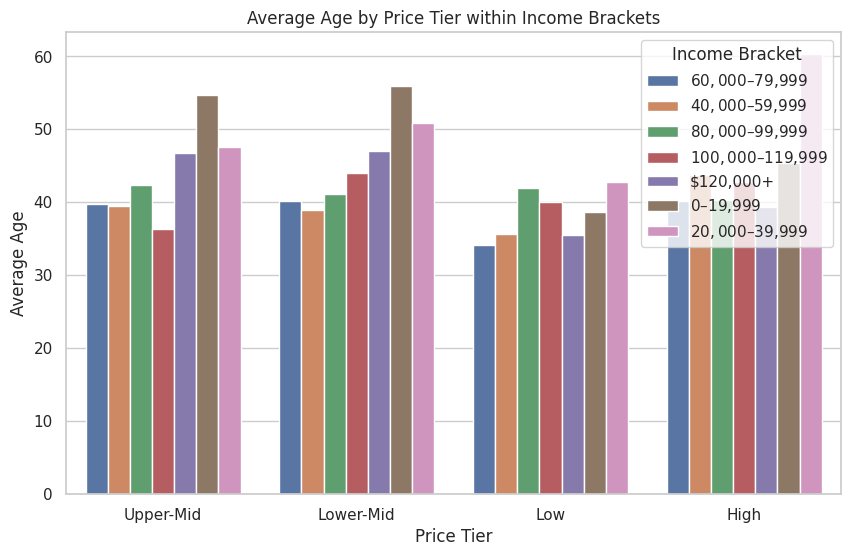

In [4]:
# -----------------------------
# 6. Visualizations of basic demographics
# -----------------------------

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Price Tier', y='age', hue='income_bracket', ci=None)
plt.title('Average Age by Price Tier within Income Brackets')
plt.xlabel('Price Tier')
plt.ylabel('Average Age')
plt.legend(title='Income Bracket')
plt.show()



### Dependents by Price Tier within Income Bracket
We see that high income bracket groups of `$100-119K` that choose lower-mid priced properties have the highest number of dependents on average. This could be explain as larger families have larger aggregated household incomes but lower per head income.

/tmp/ipython-input-2169376856.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Price Tier', y='dependents', hue='income_bracket', ci=None)


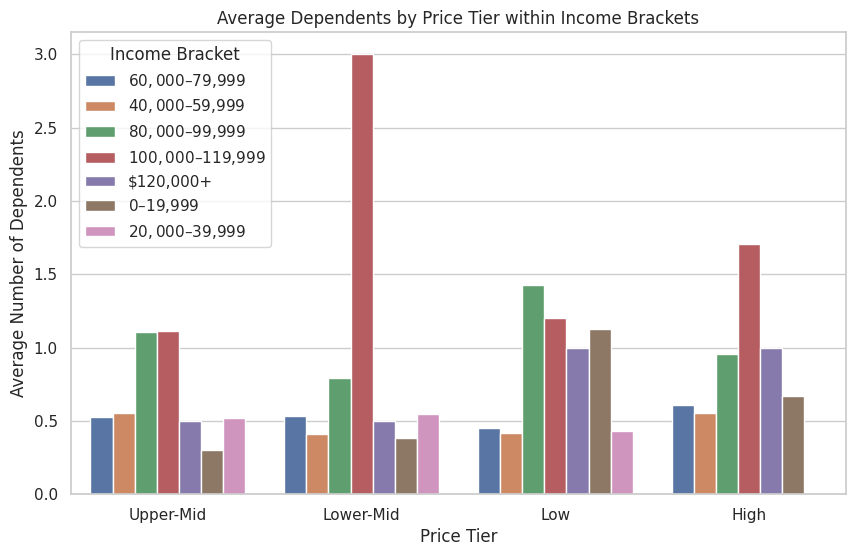

In [6]:
# Dependents by Price Tier within Income Bracket
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Price Tier', y='dependents', hue='income_bracket', ci=None)
plt.title('Average Dependents by Price Tier within Income Brackets')
plt.xlabel('Price Tier')
plt.ylabel('Average Number of Dependents')
plt.legend(title='Income Bracket')
plt.show()


### Household Size by Price Tier per Income Bracket
We notice a similar observation as `Dependents by Price Tier within Income Bracket`, possibly due to correlation between household size and number of dependents.

/tmp/ipython-input-699904552.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(['income_bracket', 'Price Tier'])['hh_size'].mean().reset_index()


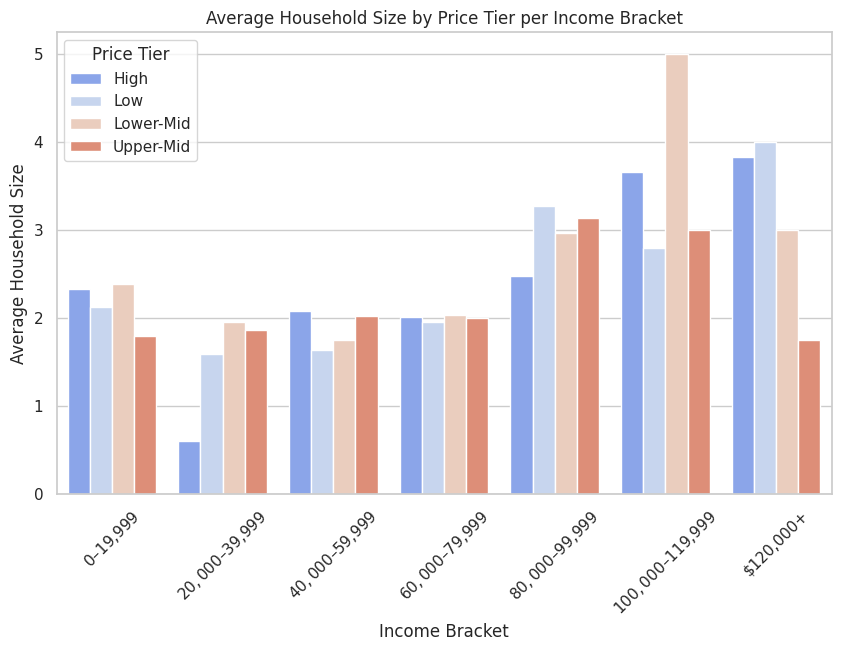

In [8]:

# Household Size by Price Tier per Income Bracket
income_order = [
    '$0–$19,999', '$20,000–$39,999', '$40,000–$59,999',
    '$60,000–$79,999', '$80,000–$99,999', '$100,000–$119,999', '$120,000+'
]
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=income_order, ordered=True)

agg_df = df.groupby(['income_bracket', 'Price Tier'])['hh_size'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=agg_df,
    x='income_bracket',
    y='hh_size',
    hue='Price Tier',
    palette='coolwarm'
)
plt.title("Average Household Size by Price Tier per Income Bracket")
plt.ylabel("Average Household Size")
plt.xlabel("Income Bracket")
plt.xticks(rotation=45)
plt.legend(title="Price Tier")
plt.show()


### Number of Properties per Town by Price Tier
Popular towns for Low-tier properties:
- Lakeville
- Tyngsborough
- Norfolk

Popular towns for Low-mid tier properties:
- Billerica
- Sandwich


Popular towns for Upper-mid tier properties:
- Foxborough
- Medway

Popular towns for High-tier properties:
- Ayer
- Hingham



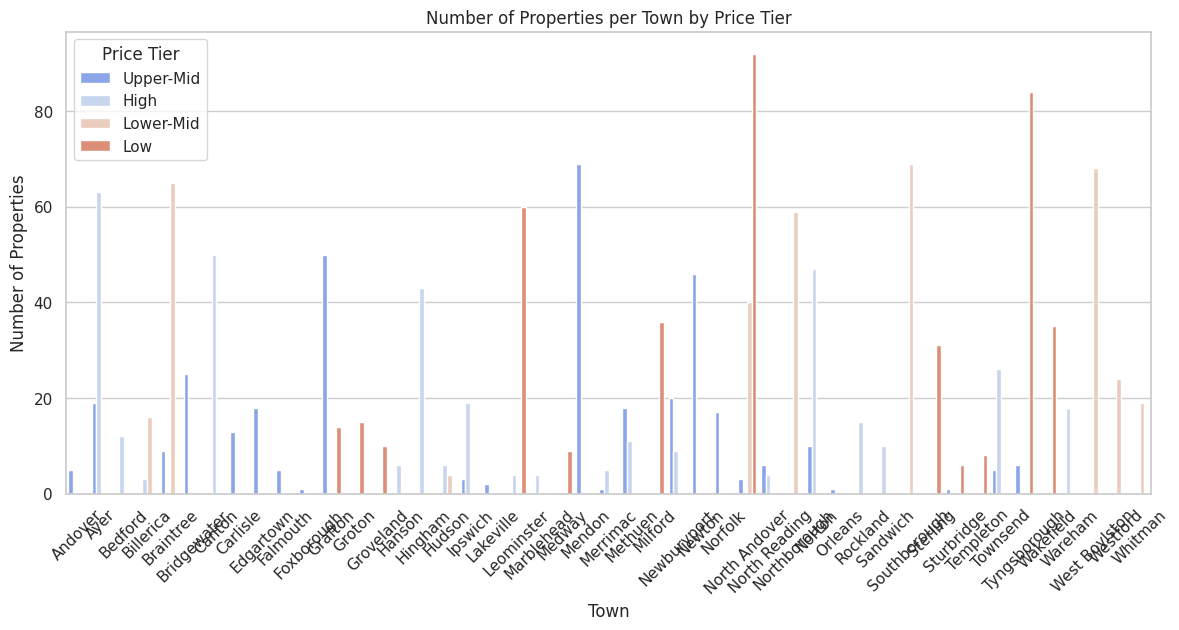

In [11]:
# -----------------------------
# 8. Number of Properties per Town by Price Tier
# -----------------------------
df_plot = df.dropna(subset=['Town', 'Price Tier', 'hh_income'])
plt.figure(figsize=(14,6))
sns.countplot(
    data=df_plot,
    x='Town',
    hue='Price Tier',
    palette='coolwarm'
)
plt.title("Number of Properties per Town by Price Tier")
plt.ylabel("Number of Properties")
plt.xlabel("Town")
plt.xticks(rotation=45)
plt.legend(title="Price Tier")
plt.show()



### Correlation heatmaps for numeric variables

/tmp/ipython-input-243872820.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bracket, sub in df.groupby('income_bracket'):


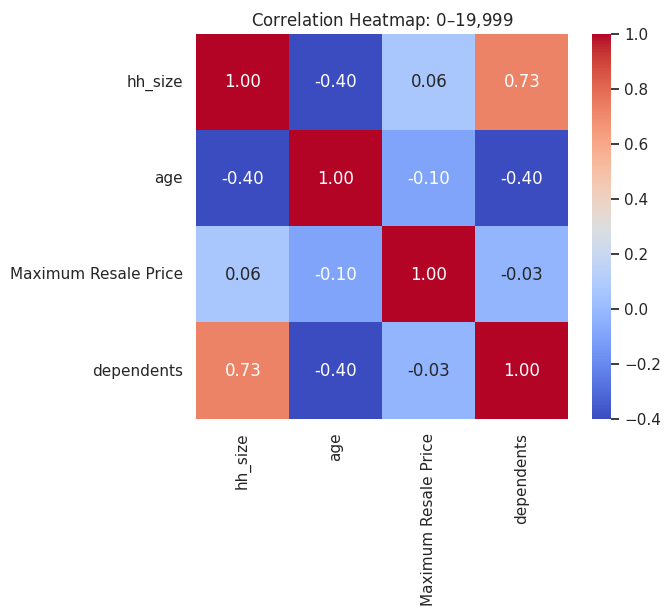

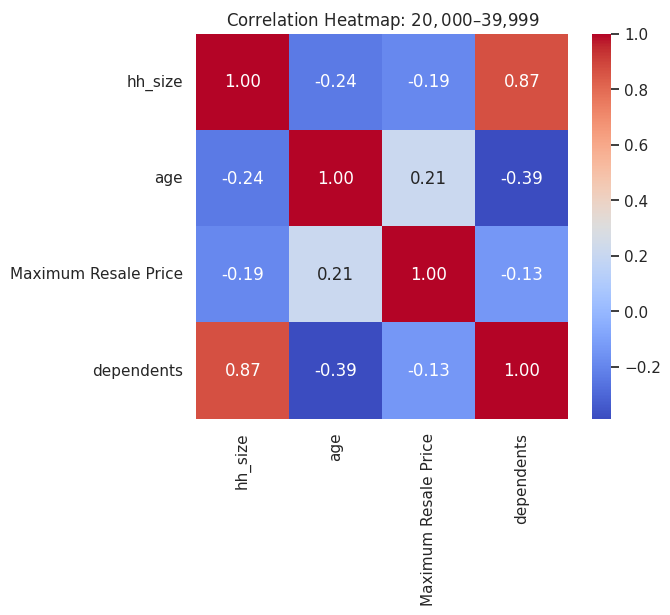

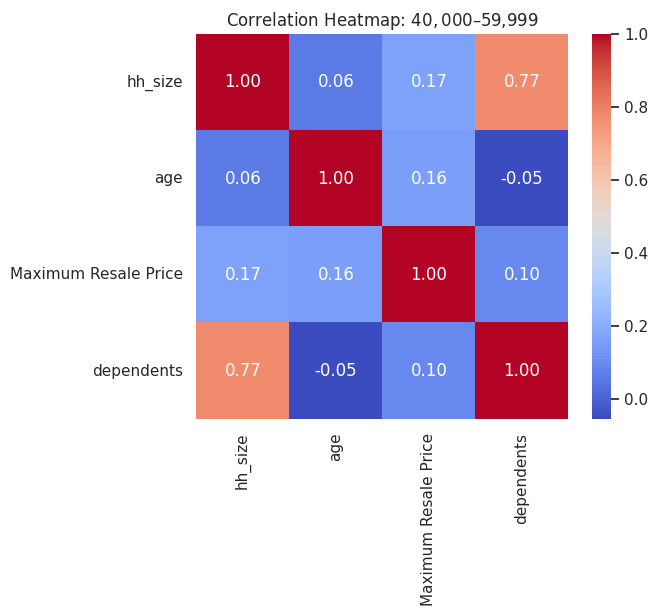

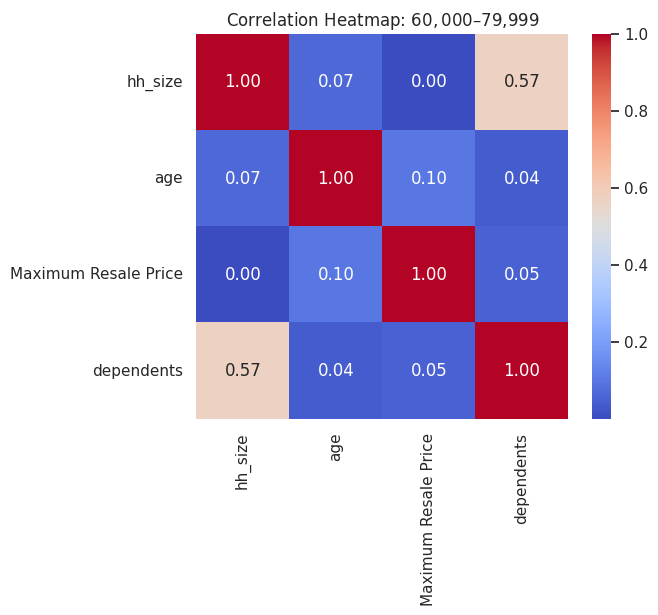

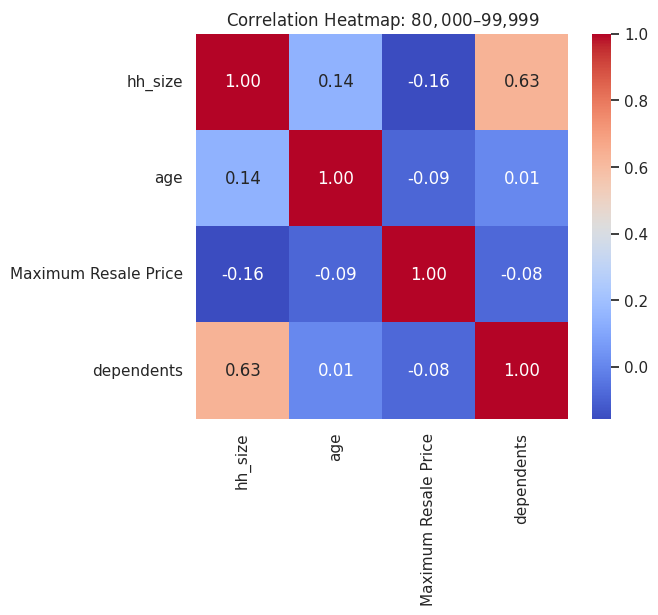

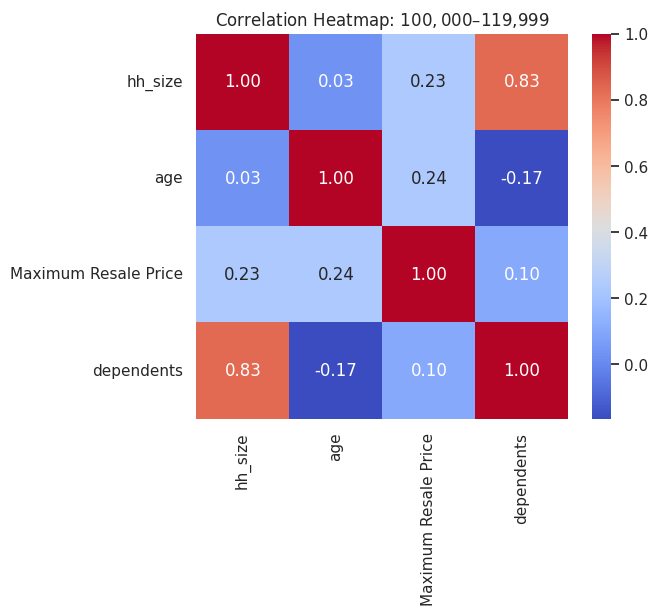

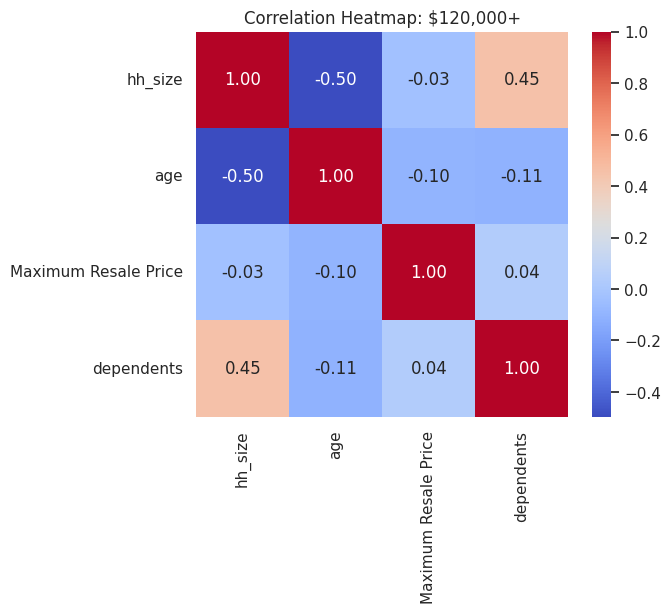

In [16]:
# -----------------------------
# 10. Correlation heatmaps for numeric variables
# -----------------------------
numeric_cols = ['hh_size', 'age', 'Maximum Resale Price', 'dependents']

for bracket, sub in df.groupby('income_bracket'):
    corr_matrix = sub[numeric_cols].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f"Correlation Heatmap: {bracket}")
    plt.show()



## Regression Analysis
The following section includes analysis of:
1. Age vs Maximum resale price (with and without interaction terms)
2. Household size vs Maximum resale price (with and without interaction terms)

Certain demographic variables have not been included in this notebook as they showed no statistically significant patterns with Maximum resale price

### Overview plot of Age vs Maximum Resale Price
Conclusions: In the `$20K–$39K` and `$40K–$59K` income brackets, there is a statistically significant correlation indicating that older owners tend to buy slightly higher-priced homes. The relationship is weak, as reflected by the small slope values.



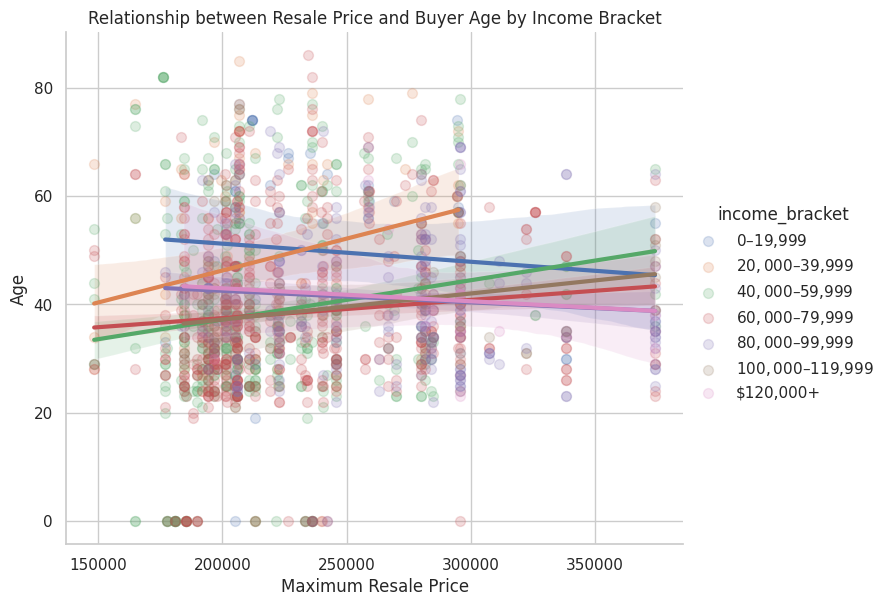

/tmp/ipython-input-528823641.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bracket, sub in df_reg.groupby('income_bracket'):
/tmp/ipython-input-528823641.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slope_df_age, x='income_bracket', y='slope_age_vs_price', palette='coolwarm')


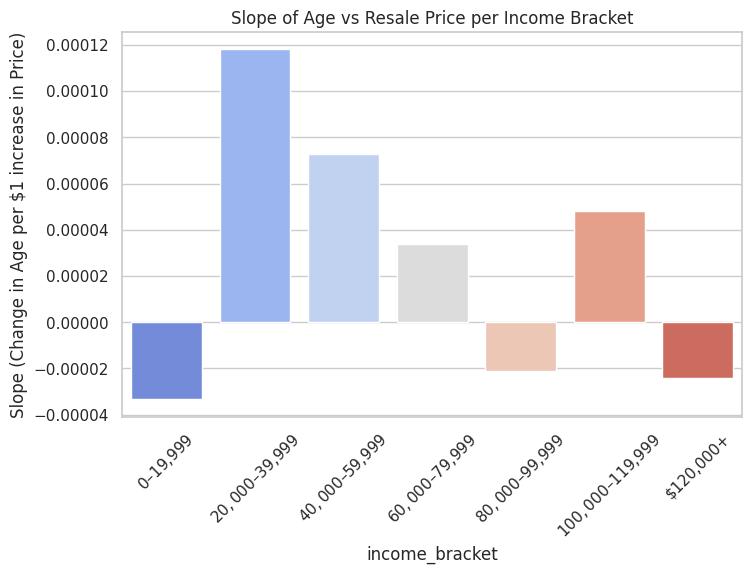

In [20]:
df_reg = df.dropna(subset=['Maximum Resale Price', 'age', 'income_bracket'])

sns.lmplot(
    data=df_reg,
    x='Maximum Resale Price',
    y='age',
    hue='income_bracket',
    height=6,
    aspect=1.2,
    scatter_kws={'alpha': 0.2, 's': 50},
    line_kws={'lw': 3}
)
plt.title("Relationship between Resale Price and Buyer Age by Income Bracket")
plt.xlabel("Maximum Resale Price")
plt.ylabel("Age")
plt.show()

results_age = {}
for bracket, sub in df_reg.groupby('income_bracket'):
    model = smf.ols('age ~ Q("Maximum Resale Price")', data=sub).fit()
    results_age[bracket] = model.params['Q("Maximum Resale Price")']

slope_df_age = pd.DataFrame({
    'income_bracket': results_age.keys(),
    'slope_age_vs_price': results_age.values()
})

plt.figure(figsize=(8,5))
sns.barplot(data=slope_df_age, x='income_bracket', y='slope_age_vs_price', palette='coolwarm')
plt.title("Slope of Age vs Resale Price per Income Bracket")
plt.ylabel("Slope (Change in Age per $1 increase in Price)")
plt.xticks(rotation=45)
plt.show()



### Interaction model: Age vs Price
Interaction terms test whether the slope of household size vs. price differs across income categories.

- The `$20,000-$40,000` bracket shows the strongest statistical relationship between price and age
- Higher-income brackets lack statistically significant age-price relationships

In [21]:
# Interaction model for age
model_age_interaction = smf.ols('age ~ Q("Maximum Resale Price") * C(income_bracket)', data=df_reg).fit()
print(model_age_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     6.274
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.28e-11
Time:                        22:08:24   Log-Likelihood:                -6105.7
No. Observations:                1472   AIC:                         1.224e+04
Df Residuals:                    1458   BIC:                         1.231e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

### Household Size vs Maximum Resale Price

The following analysis indicates that there is no meaningful relationship with household size across any income bracket.

We got similar analysis results for factors such as disability, and number of dependents, and were thus concluded to not be sensitive to property price changes.


/tmp/ipython-input-671499340.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bracket, sub in df_reg.groupby('income_bracket'):
/tmp/ipython-input-671499340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slope_df_hh, x='income_bracket', y='slope_price_on_hh_size', palette='coolwarm')


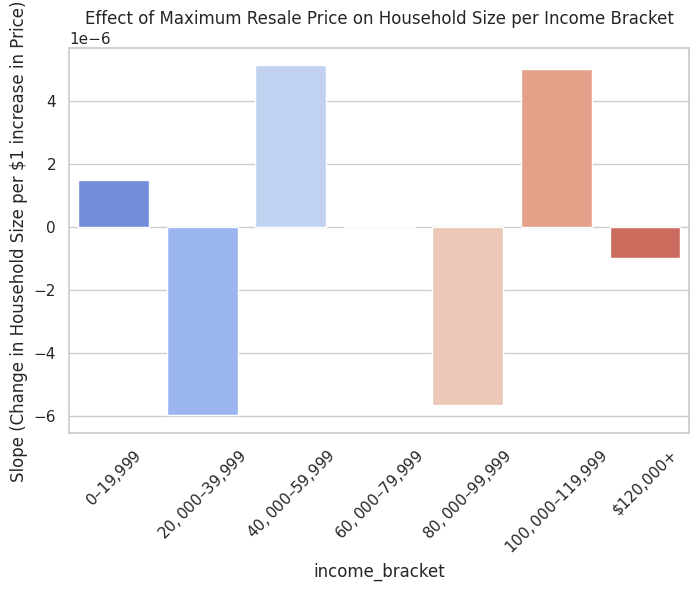

                            OLS Regression Results                            
Dep. Variable:                hh_size   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     11.50
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           5.58e-24
Time:                        22:20:34   Log-Likelihood:                -2651.5
No. Observations:                1472   AIC:                             5331.
Df Residuals:                    1458   BIC:                             5405.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [23]:
results_hh = {}
for bracket, sub in df_reg.groupby('income_bracket'):
    model = smf.ols('hh_size ~ Q("Maximum Resale Price")', data=sub).fit()
    results_hh[bracket] = model.params['Q("Maximum Resale Price")']

slope_df_hh = pd.DataFrame({
    'income_bracket': results_hh.keys(),
    'slope_price_on_hh_size': results_hh.values()
})

plt.figure(figsize=(8,5))
sns.barplot(data=slope_df_hh, x='income_bracket', y='slope_price_on_hh_size', palette='coolwarm')
plt.title("Effect of Maximum Resale Price on Household Size per Income Bracket")
plt.ylabel("Slope (Change in Household Size per $1 increase in Price)")
plt.xticks(rotation=45)
plt.show()

# Interaction model for household size
model_hh_interaction = smf.ols('hh_size ~ Q("Maximum Resale Price") * C(income_bracket)', data=df_reg).fit()
print(model_hh_interaction.summary())
